# Архітектури CNN і transfer learning
## Бізнес-контекст
Компанія MediScan AI розробляє систему для аналізу рентген-знімків.
Ви маєте провести дослідження популярних архітектур CNN і спробувати використати переднавчену модель для розпізнавання зображень.

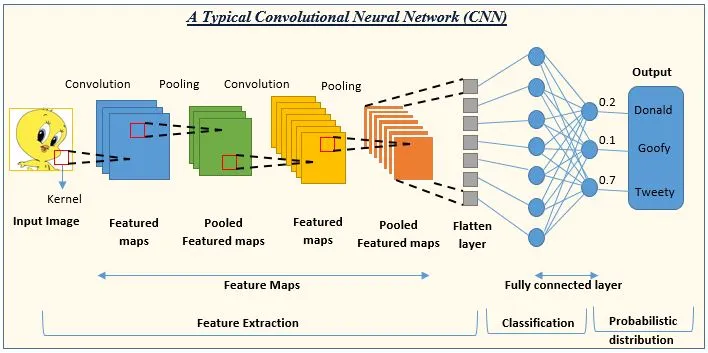

## CNN - Convolutional Neural Network - Згорткові (конволюційні) нейромережі
CNN складаються з окемих частин, одна з них призначена для обробки зображення шляхом згортки та пулінгу. Згортка - процес проходження по початковому зображенню "вікном" - послідовне накладання на зображення матриці (вікна) з обрахунком підсумку (згортки) - зображеня, меншого за вихідне на 2 пікселі з кожної розмірності. Пулінг - визначення максимуму серед групи пікселів, зазвичай, 2х2, при цьому зображення зменшується удвічі (по кожній розмірності). Дана процедура повторюється декілька разів різними ваговими "вікнами", утворюючи набори зменшених зображень.

Описана процедура може кількаразово повторюватись до зменшених зображень, утворюючи ще більшу кількість ще менших зображень. Наприкінці першої частини здійснюється формування єдиного масиву (Flatten), який містить усі залишкові пікселі усіх міні-зображень послідовно (як лінійний масив)

Друга частина є звичайною нейромережею (перцептроном), для якої лінійний масив є входом, а вихід залежить від кількості класів з якими співставляються початкові зображення. Причому сама класифікація здійснюється шляхом вибору вихідного (R) нейрона з максимальним збудженням.

## Завдання 1
Вивчіть три класичні архітектури: LeNet, AlexNet, ResNet. Коротко опишіть їхні відмінності у вигляді таблиці:
|Архітектура|Кількість шарів|Особливості|Застосування|
|-|-|-|-|
|LeNet (1998)|5 (2 convolutional and 3 full layers)|60k parameters|Розпізнавання рукописних цифр|
|AlexNet (2012)|8 (5 convolutional and 3 fully connected)|60M parameters|Класифікація зображень|
|ResNet (2015)|18 - 152 (лише останній лінійний)|11М - 60М parameters|Комп'ютерний зір (розпізнавання образів)|

## Завдання 2
Завантажте датасет CIFAR-10 з torchvision.datasets.
- Виконайте нормалізацію.
- Створіть DataLoader.
- Перевірте структуру одного батча (розмір, форма, тип даних).

In [3]:
import torch
import torchvision
import torchvision.transforms as transforms

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize( (0.5,0.5,0.5), (0.5,0.5,0.5) )   # для кольорових зображень по три параметри (RGB)
])

trainset = torchvision.datasets.CIFAR10(
    download=True,
    root="./data",
    transform=transform,
    train=True
)

testset = torchvision.datasets.CIFAR10(
    download=True,
    root="./data",
    transform=transform,
    train=False
)

100.0%


In [5]:
batch_size = 4

trainloader = torch.utils.data.DataLoader(
    trainset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=2
)
testloader = torch.utils.data.DataLoader(
    testset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=2
)

In [6]:
import matplotlib.pyplot as plt
import numpy as np

def imshow(img) :
    img = img * 0.5 + 0.5  # Денормалізація - множимо на дисперсію та додаємо середнє
    img = img.numpy().clip(0,1)  # Обмежуємо вихід кольору за межі 0-1
    img = np.transpose(img, (1,2,0))  # Перетворюємо тензори з кольорами на послідовність двомірних точок
    plt.imshow(img)
    plt.show()